HTML(value='<style>.cell-output-ipywidget-background {\n   background-color: transparent !important;\n}\n.jp-O…

Checkbox(value=True, description='Enable Atmospheric Drag')

Checkbox(value=True, description='Enable Radiant Temp')

FloatSlider(value=0.010000000000000009, description='Target offset Earth angle', layout=Layout(width='500px'),…

FloatSlider(value=2.0, description='Thrust angle', layout=Layout(width='500px'), max=3.141592653589793, step=0…

...

IntSlider(value=252, description='Flight time - Guess', layout=Layout(width='500px'), max=500, min=10)

FloatSlider(value=2.3200000000000003, description='Velocity - Guess', layout=Layout(width='500px'), max=5.0, s…

Button(description='Run', style=ButtonStyle())

utils.py:324  Loaded Cache Result guess: [ 49.42172617 229.35739978]	 distance: 4.943935817919125e-14
utils.py:292  Saving result to cache cache\__main__\target_dist\data.pkl
utils.py:98  minimize_cached took 10.9044 seconds
2664219425.py:89  postOptimization Err: 0.000 km
2664219425.py:112  Optimized t_flight: 230.10 s
2664219425.py:113  Optimized velocity: 53.29 km / s


c:\Users\jcl5m\miniconda3\lib\site-packages\scipy\integrate\_ode.py:1179: UserWarning: dopri5: step size becomes too small
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,
c:\Users\jcl5m\miniconda3\lib\site-packages\scipy\integrate\_ode.py:1179: UserWarning: dopri5: step size becomes too small
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


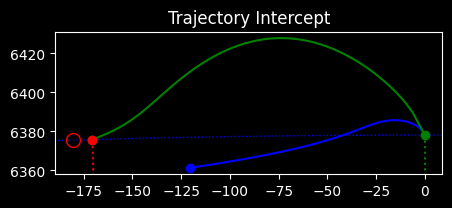

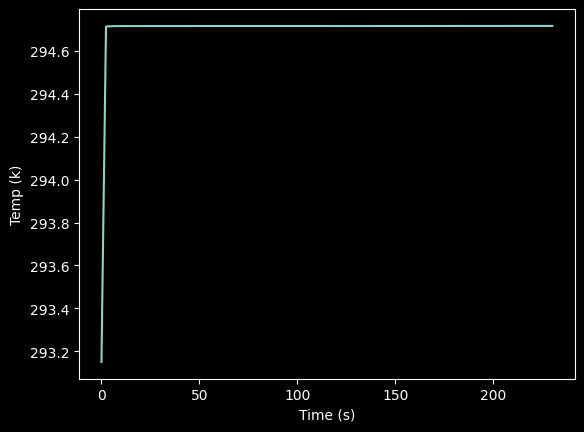

In [ ]:
# interactive trajectory intercept minimizer

import matplotlib.pyplot as plt
from IPython.display import clear_output
from ipywidgets import interact, IntSlider, FloatSlider, Layout, interactive, Button, HTML, Checkbox
import numpy as np
from orbitengine.body import Body
import orbitengine.engine as oe
import astropy.units as u
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import time

import orbitengine.utils as util
import time


width = '500px'
target_offset_angle_slider = FloatSlider(min=-.5, max=.1, value=0.01,step=0.01, layout=Layout(width=width), description='Target offset Earth angle')
thrust_angle_slider = FloatSlider(min=0, max=np.pi, value=2.00,step=0.01, layout=Layout(width=width), description='Thrust angle')
mass_slider = FloatSlider(min=10, max=10000, step=1, value=5000, layout=Layout(width=width), description='Mass')
radius_slider = FloatSlider(min=0.001, max=2, step=.001, value=1, layout=Layout(width=width), description='Radius')
t_flight_slider = IntSlider(min=10, max=500,value=189, layout=Layout(width=width), description='Flight time - Guess')
velocity_slider = FloatSlider(min=0, max=5, step=0.01, value=2.12, layout=Layout(width=width), description='Velocity - Guess')
style_html = HTML('<style>' + open('notebook_darkmode.css').read() + '</style>')

# Create the checkbox
drag_checkbox = Checkbox(value=False, description='Enable Atmospheric Drag')
temp_checkbox = Checkbox(value=False, description='Enable Radiant Temp')


def target_dist(x, thrust_angle, state_init, state_target, acc_params=None):
    velocity, t_flight = x
    v = util.spherical_to_cartesian(np.array([velocity, np.pi/2, thrust_angle]))*u.km/u.s
    
    state_maneuver = Body.State(state_init.position, 
                                v,
                                state_init.mass)

    sm = state_maneuver.propagate(oe.EARTH_K, t_flight*u.s, acc_params=acc_params)
    st = state_target.propagate(oe.EARTH_K, t_flight*u.s)

    dp = np.linalg.norm(st.position - sm.position).value
    return dp


def intercept_calc(target_offset_earth_angle, 
      thrust_angle, 
      t_flight, 
      velocity, 
      mass, 
      radius,
      enable_drag, 
      enable_temp):

    # Define a function that creates a plot
    state_init = Body.State(
    np.array([0,oe.EARTH_RADIUS_KM, 0])*u.km, 
    oe.V_ZERO, 
    mass*u.kg, 
    parent_axis_angle=oe.EARTH_AXIS_ANGLE_Z)

    # compute inital target position based on the offset angle
    rot_target = R.from_euler('z', target_offset_earth_angle)
    state_target = Body.State(rot_target.apply(state_init.position)*u.km, 
                              oe.V_ZERO, 
                              mass*u.kg,
                              parent_axis_angle=oe.EARTH_AXIS_ANGLE_Z)

    x0 = [velocity, t_flight]

    acc_params = oe.AccParams(
        axial_cross_section=np.pi*(radius*u.m)**2,
        atmosphere_axial_drag_coefficient=0.3,
        enable_drag=enable_drag)

    bounds = [(0, 100), (1, 5000)]

    res = util.minimize_cached(
                target_dist,
                x0, 
                cache_tol=1e-2,
                bounds=bounds,
                args=(thrust_angle, 
                        state_init, 
                        state_target, 
                        acc_params))

    util.print(f"postOptimization Err: {res.fun*u.km:.3f}")

    # guess maneuver
    v = util.spherical_to_cartesian(np.array([velocity, np.pi/2, thrust_angle]))*u.km/u.s
    state_guess_maneuver = Body.State(state_init.position, 
                                      v,
                                      state_init.mass)

    ts1 = np.linspace(0, t_flight*u.s, 100)
    sgm = state_guess_maneuver.propagate(oe.EARTH_K, ts1, acc_params=acc_params)
    st_guess = state_target.propagate(oe.EARTH_K, t_flight*u.s)

    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))

    # plot original inital guess maneuver trajectory
    axs.plot([s.position[0].value for s in sgm], [s.position[1].value for s in sgm], color='b')
    axs.plot(sgm[-1].position[0].value, sgm[-1].position[1].value, 'bo')
    axs.plot(st_guess.position[0].value, st_guess.position[1].value, 'ro',
              markerfacecolor='none', markeredgecolor='r', markersize=10)

    # optimized maneuver
    velocity, t_flight = res.x
    util.print(f"Optimized t_flight: {t_flight*u.s:.2f}")
    util.print(f"Optimized velocity: {velocity*u.km/u.s:.2f}")
    v = util.spherical_to_cartesian(np.array([velocity, np.pi/2, thrust_angle]))*u.km/u.s
    state_optimized_maneuver = Body.State(state_init.position,
                                           v,
                                           state_init.mass, 
                                           T=oe.TEMP_EARTH)

    #plot optimized trajectory
    ts2 = np.linspace(0, t_flight*u.s, 100)
    acc_params.enable_temp = enable_temp
    sm2 = state_optimized_maneuver.propagate(oe.EARTH_K, ts2, acc_params=acc_params)
    axs.plot([s.position[0].value for s in sm2], [s.position[1].value for s in sm2],color='g')
    axs.plot(sm2[-1].position[0].value, sm2[-1].position[1].value, 'go')

    st_final = state_target.propagate(oe.EARTH_K, t_flight*u.s)
    axs.plot(st_final.position[0].value, st_final.position[1].value, 'ro')


    axs.add_artist(plt.Line2D((0, st_final.position[0].value), (0, st_final.position[1].value), color='r', linestyle='dotted'))
    axs.plot(state_init.position[0].value, state_init.position[1].value, 'go')
 
    circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM, color='b', fill=False, linestyle='dotted')
    axs.add_artist(circle)
    axs.add_artist(plt.Line2D((0, state_init.position[0].value), (0, state_init.position[1].value), color='g', linestyle='dotted'))
    axs.set_aspect('equal', adjustable='box')
    plt.title('Trajectory Intercept')
    plt.show()


    plt.plot(ts2, [s.temperature.value for s in sm2])
    plt.ylabel('Temp (k)')
    plt.xlabel('Time (s)')
    plt.show()



# Define a function to be run when the button is clicked
def on_button_clicked(b):

    clear_output(wait=True)
    display(style_html,
            drag_checkbox,
            temp_checkbox,
            target_offset_angle_slider,
            thrust_angle_slider, 
            mass_slider, 
            radius_slider,
            t_flight_slider, 
            velocity_slider, 
            button)
    

    # Get the current values of the sliders
    target_angle = target_offset_angle_slider.value
    thrust_angle = thrust_angle_slider.value
    t_flight = t_flight_slider.value
    velocity = velocity_slider.value
    mass = mass_slider.value
    enable_drag = drag_checkbox.value
    enable_temp = temp_checkbox.value
    radius = radius_slider.value
    # Call your function with these values    
    intercept_calc(target_angle, 
                   thrust_angle, 
                   t_flight, 
                   velocity, 
                   mass, 
                   radius, 
                   enable_drag, 
                   enable_temp)

# Set this function to be called when the button is clicked
button = Button(description="Run")

button.on_click(on_button_clicked)

on_button_clicked(button)


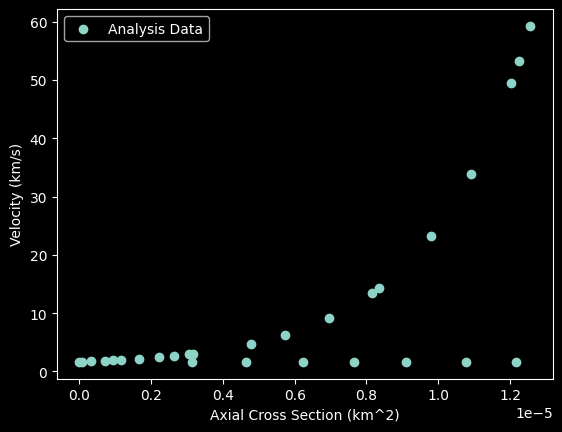

In [26]:
import os
import pandas as pd
path = os.path.join(util.CACHE_DIR, '__main__','target_dist','data.pkl')
data_df = pd.read_pickle(path)

# extract dictionary column from data_df['data']
data = data_df['data'].apply(lambda x: (x['result']['x'][0], x['result']['x'][1], x['kwargs']['args'][3].axial_cross_section)).tolist()
data = np.array(data)
plt.scatter(data[:, 2], data[:, 0], label='Analysis Data')
plt.xlabel("Axial Cross Section (km^2)")
plt.ylabel("Velocity (km/s)")
plt.legend()
plt.show()


[ 10.09281501 174.35304319]


Floats: [1.5 2.3 7.1], Label: vector1
Floats: [3.8 0.4 2.5], Label: vector2
